## Laboratorio 2.
#### Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Al desarrollar este laboratorio pondrás a prueba tus habilidades para:

Identificar y abordar preguntas de negocio y de analytics.
Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
Explorar, modificar, limpiar y unir objetos tablas de datos.
Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
Implementar análisis basado en modelos estadísticos o de machine learning.

### Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11.

Los objetivos de este caso de estudio son:

Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.
Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.
Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el stakeholder.
Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

### Fase 1: obtener e inspeccionar archivos.

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos append o concat si eliges cargarlos utilizando la librería pandas).
Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.
Preguntas guía:

¿Qué dimensiones tienen los datos?
¿Con cuántos años y periodos de evaluación se cuenta?
¿Cuáles variables pueden ser de interés para la problemática planteada?
¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# Leer DataFrame de primer y segundo semestre 2020
primer_semestre_2020 = pd.read_csv('Saber_11°_2020-1.csv')
segundo_semestre_2020 = pd.read_csv('Saber_11°_2020-2.csv')

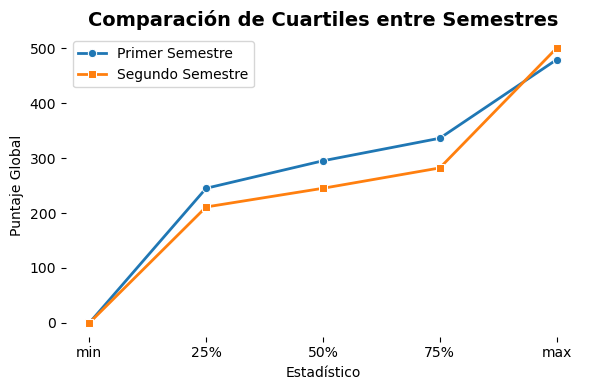

In [3]:
# Validar de manera rápida las estadísticas de ambos semestres con relación al puntaje global para considerar unir los DataFrame
estadisticas_puntaje_primer_semestre = primer_semestre_2020['PUNT_GLOBAL'].describe()
estadisticas_puntaje_segundo_semestre= segundo_semestre_2020['PUNT_GLOBAL'].describe()

# Graficar plot para visualizar las diferencias en cuartiles de ambos semestres.
x_sem1 = estadisticas_puntaje_primer_semestre.index[3:]
y_sem1 = estadisticas_puntaje_primer_semestre[3:]

# Extraer datos del segundo semestre
x_sem2 = estadisticas_puntaje_segundo_semestre.index[3:]
y_sem2 = estadisticas_puntaje_segundo_semestre[3:]

plt.figure(figsize=(6, 4))

# Línea para el Primer Semestre
sns.lineplot(x=x_sem1, y=y_sem1, marker='o', label='Primer Semestre', linewidth=2)

# Línea para el Segundo Semestre
sns.lineplot(x=x_sem2, y=y_sem2, marker='s', label='Segundo Semestre', linewidth=2)

plt.title('Comparación de Cuartiles entre Semestres', fontsize=14, fontweight='bold')
plt.ylabel('Puntaje Global')
plt.xlabel('Estadístico')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# A pesar de observar mejores resultados (promedio y percentiles) en las pruebas realizadas en el primer semestre en comparación con las presentadas en segundo semestre, lo mejor es unir los DataFrame.

In [4]:
# Crear función para concatenar DataFrames por coincidencia de columnas.
def concatenar_df(df1, df2):
    concatenar = pd.concat([df1, df2], ignore_index=True)
    return concatenar

df_pruebas_saber_2020 = concatenar_df(primer_semestre_2020, segundo_semestre_2020) # DataFrame total pruebas presentadas 2020.

# Organizar los datos descendemente por 'PUNT_GLOBAL' y dar un index que comience desde el puesto n° 1.
df_pruebas_saber_2020 = df_pruebas_saber_2020.sort_values(by='PUNT_GLOBAL', ascending=False)
df_pruebas_saber_2020.index = range(1, len(df_pruebas_saber_2020)+1)

# Revisar cantidad de datos Nan por columna
datos_nan = df_pruebas_saber_2020.isna().sum()
# La totalidad de datos Nan se ubican en columnas de variables categóricas. Por lo cual, lo mejor es atribuirles el valor de 'Sin Información' para manejarlos correctamente.

# Rellenar las celdas Nan con 'Sin Información'
df_pruebas_saber_2020 = df_pruebas_saber_2020.fillna('Sin Información')
datos_nan = df_pruebas_saber_2020.isna().sum() # Verificar nuevamente que el cambio se efectuó.

In [5]:
# Hallar y organizar las columnas más relevantes para la búsqueda y clasificación de información. Haré tres grupos diferenciados por puntajes, formación académica y entorno sociocultural.

df_puntajes_2020 = df_pruebas_saber_2020[['PUNT_LECTURA_CRITICA',
       'PERCENTIL_LECTURA_CRITICA',
       'PUNT_MATEMATICAS', 'PERCENTIL_MATEMATICAS',
       'PUNT_C_NATURALES', 'PERCENTIL_C_NATURALES', 
       'PUNT_SOCIALES_CIUDADANAS', 'PERCENTIL_SOCIALES_CIUDADANAS',
       'PUNT_INGLES', 'PERCENTIL_INGLES',
       'PUNT_GLOBAL', 'PERCENTIL_GLOBAL']] 

df_formacion_2020 = df_pruebas_saber_2020[['COLE_GENERO','COLE_CALENDARIO', 
       'COLE_BILINGUE', 'COLE_CARACTER', 'COLE_JORNADA', 
       'COLE_MCPIO_UBICACION', 'ESTU_MCPIO_PRESENTACION', 'COLE_DEPTO_UBICACION',
       'ESTU_DEPTO_PRESENTACION', 'ESTU_DEDICACIONLECTURADIARIA', 'ESTU_DEDICACIONINTERNET',
       'ESTU_HORASSEMANATRABAJA', 'ESTU_TIPOREMUNERACION']]

df_sociocultural_2020 = df_pruebas_saber_2020[['ESTU_GENERO', 'ESTU_TIENEETNIA', 
        'ESTU_NACIONALIDAD', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_CUARTOSHOGAR', 
        'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE', 'FAMI_TRABAJOLABORPADRE', 
        'FAMI_TRABAJOLABORMADRE', 'FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV',
        'FAMI_TIENECOMPUTADOR', 'FAMI_TIENELAVADORA', 'FAMI_TIENEHORNOMICROOGAS', 
        'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS',
        'FAMI_NUMLIBROS', 'FAMI_COMELECHEDERIVADOS', 'FAMI_COMECARNEPESCADOHUEVO',
        'FAMI_COMECEREALFRUTOSLEGUMBRE', 'FAMI_SITUACIONECONOMICA']]


In [6]:
# Crear una función para unir DataFrames:

def union_de_df(primer_df, segundo_df):
    validacion = set(segundo_df.columns).issubset(primer_df.columns)
    if not validacion:
        union = primer_df.merge(segundo_df, left_index=True, right_index=True)
    return union

# Dataframes 2020
puntaje_formacion_2020 = union_de_df(df_puntajes_2020, df_formacion_2020)            # DataFrame de puntaje y formación.
puntaje_sociocultural_2020 = union_de_df(df_puntajes_2020, df_sociocultural_2020)    # DataFrame de puntaje y sociocultural.
df_2020 = union_de_df(puntaje_formacion_2020, df_sociocultural_2020)                 # DataFrame completo 2020

# Retirar los valores de 'PUNT_GLOBAL' iguales a 0, presumiendo que fueron pruebas anuladas o no presentadas.
df_2020 = df_2020[(df_2020['PUNT_GLOBAL'] > 0)].copy()

# Generar muestra aleatoria de 1000 obervciones requeridas.
df_2020 = df_2020.sample(n=1000, random_state=1)
df_2020.shape

(1000, 48)

### Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
Utilizar librerías especializadas (ej., matplotlib, seaborn, etc.) para inspeccionar visualmente variables de interés. Los métodos distplot, pairplot, boxplot, o violinplot, entre otros, pueden ser útiles.
Utilizar el método groupby de pandas, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.
Preguntas guía:

¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
¿Sobre cuáles variables harías un análisis más profundo?

In [7]:
# Estrategias para hallar patrones con base en las estadísticas de 'PUNT_GLOBAL'.

# Crear función que agrupe variable requerida y devuelva estadísticas del puntaje global (O cualquier otro puntaje ingresado).
def agrupamiento_por_variable(columna, puntaje_requerido):
    variable_puntaje = df_2020.groupby(columna)[puntaje_requerido].describe().sort_values(by='mean', ascending=False)
    return variable_puntaje

# Agrupación individual de variable con PUNT_GLOBAL y sus estadísticas. pruebas saber 2020.
estadisticas_municipio = agrupamiento_por_variable('ESTU_MCPIO_PRESENTACION', 'PUNT_GLOBAL') 
estadisticas_departamento = agrupamiento_por_variable('ESTU_DEPTO_PRESENTACION', 'PUNT_GLOBAL') 
estadisticas_tiempo_int = agrupamiento_por_variable('ESTU_DEDICACIONINTERNET', 'PUNT_GLOBAL')
estadisticas_tiempo_lect = agrupamiento_por_variable('ESTU_DEDICACIONLECTURADIARIA', 'PUNT_GLOBAL')
estadisticas_horas_trabajo = agrupamiento_por_variable('ESTU_HORASSEMANATRABAJA', 'PUNT_GLOBAL')
estadisticas_cole_calendario = agrupamiento_por_variable('COLE_CALENDARIO', 'PUNT_GLOBAL')
estadisticas_cole_jornada = agrupamiento_por_variable('COLE_JORNADA', 'PUNT_GLOBAL')
estadisticas_estrato = agrupamiento_por_variable('FAMI_ESTRATOVIVIENDA', 'PUNT_GLOBAL')
estadisticas_edu_padre = agrupamiento_por_variable('FAMI_EDUCACIONPADRE', 'PUNT_GLOBAL')
estadisticas_edu_madre = agrupamiento_por_variable('FAMI_EDUCACIONMADRE', 'PUNT_GLOBAL')
estadisticas_trab_padre = agrupamiento_por_variable('FAMI_TRABAJOLABORPADRE', 'PUNT_GLOBAL')
estadisticas_trab_madre = agrupamiento_por_variable('FAMI_TRABAJOLABORMADRE', 'PUNT_GLOBAL')
estadisticas_num_libros = agrupamiento_por_variable('FAMI_NUMLIBROS', 'PUNT_GLOBAL')
estadisticas_tiene_int = agrupamiento_por_variable('FAMI_TIENEINTERNET', 'PUNT_GLOBAL')
estadisticas_tiene_serv_tv = agrupamiento_por_variable('FAMI_TIENESERVICIOTV', 'PUNT_GLOBAL')
estadisticas_tiene_pc = agrupamiento_por_variable('FAMI_TIENECOMPUTADOR', 'PUNT_GLOBAL')
estadisticas_tiene_lavadora = agrupamiento_por_variable('FAMI_TIENELAVADORA', 'PUNT_GLOBAL')
estadisticas_tiene_microogas = agrupamiento_por_variable('FAMI_TIENEHORNOMICROOGAS', 'PUNT_GLOBAL')
estadisticas_tiene_carro = agrupamiento_por_variable('FAMI_TIENEAUTOMOVIL', 'PUNT_GLOBAL')
estadisticas_tiene_moto = agrupamiento_por_variable('FAMI_TIENEMOTOCICLETA', 'PUNT_GLOBAL')
estadisticas_tiene_consola = agrupamiento_por_variable('FAMI_TIENECONSOLAVIDEOJUEGOS', 'PUNT_GLOBAL')
estadisticas_lechederivados = agrupamiento_por_variable('FAMI_COMELECHEDERIVADOS', 'PUNT_GLOBAL')
estadisticas_carnepescadohuevo = agrupamiento_por_variable('FAMI_COMECARNEPESCADOHUEVO', 'PUNT_GLOBAL')
estadisticas_cerealfrutoslegumbre = agrupamiento_por_variable('FAMI_COMECEREALFRUTOSLEGUMBRE', 'PUNT_GLOBAL')

In [8]:
# Crear función que soporte visualmente las estadístias recién creadas con base a PUNT_GLOBAL (O cualquier otro puntaje ingresado) para revisar varibales individualmente según estadísticas y conteo de evaluados por caractéristicas:

# Boxplot que recibe DatFrame, variable y puntaje como parámetros y devuelve los cuartiles de puntaje según variable.
def grafica_boxplot(df ,variable, puntaje): # NO recomendada para variables con diverso flujo de respuestas (Como municipio o departamento).
    plt.figure(figsize=(10,6))
    ax = sns.boxplot(
        data=df, 
        x=variable, 
        y=puntaje,
        width=0.5,
        fliersize=3,
        linewidth=1.2)
    condicion = df[variable].nunique()
    sns.despine(left=True, bottom=True)
    if condicion > 4:
        plt.xticks(rotation=25, ha='right', fontsize=7)
    plt.title(
        f'Distribución de puntaje según {variable}',
        fontsize=14,
        pad=30,
        fontweight='bold')
    plt.tight_layout()
    plt.show()

# Bars que recibe estadística_variable y nombre de la estadística que se quiere consultar ('count', 'min', 'max'...) 
def grafica_barras(estadistica_variable, nombre_estadistica):
    plt.figure(figsize=(10,6))
    eje_x = estadistica_variable.index
    eje_y = estadistica_variable[nombre_estadistica]
    ax = sns.barplot(data=estadistica_variable, x= eje_x, y=eje_y )
    if len(eje_x) > 4:
        plt.xticks(rotation=25, ha='right', fontsize=7)
    plt.title(
        f'Número de evaluados según {estadistica_variable.index.name}',
        fontsize=14,
        fontweight='bold',
        pad=30)
    sns.despine(left=True, bottom=True)
    plt.show()    

# Algunas gráficas individuales empacadas por barras y boxplot para observar según interés.

# graficas_tiempo_int = grafica_barras(estadisticas_tiempo_int, 'count'), grafica_boxplot(df_2020, 'ESTU_DEDICACIONINTERNET', 'PUNT_GLOBAL')
# graficas_tiempo_lect = 'PUNT_GLOBAL'), grafica_barras(estadisticas_tiempo_lect, 'count'), grafica_boxplot(df_2020, 'ESTU_DEDICACIONLECTURADIARIA'
# graficas_horas_trabajo = grafica_barras(estadisticas_horas_trabajo, 'count'), grafica_boxplot(df_2020, 'ESTU_HORASSEMANATRABAJA', 'PUNT_GLOBAL')
# graficas_cole_calendario = grafica_barras(estadisticas_cole_calendario, 'count'), grafica_boxplot(df_2020, 'COLE_CALENDARIO', 'PUNT_GLOBAL')
# grafica_lechederivados = grafica_barras(estadisticas_lechederivados, 'count'), grafica_boxplot(df_2020, 'FAMI_COMELECHEDERIVADOS', 'PUNT_GLOBAL')
# grafica_carnepescadohuevo = grafica_barras(estadisticas_carnepescadohuevo, 'count'), grafica_boxplot(df_2020, 'FAMI_COMECARNEPESCADOHUEVO', 'PUNT_GLOBAL')
# grafica_cerealfrutoslegumbre = grafica_barras(estadisticas_cerealfrutoslegumbre, 'count'), grafica_boxplot(df_2020, 'FAMI_COMECEREALFRUTOSLEGUMBRE', 'PUNT_GLOBAL')

In [9]:
# Variables de interés para este proyecto:

# 1.(BIENESTAR)
# Escogidas por ser indicadores de bienestar presente al referir posesión sobre un bien o un servicio de necesidad secundaria (No indispensables para supervivencia biológica, pero ofrecen bienestar).
# Por sí solas no generan afección aparente, pues la media de 'PUNT_GLOBAL' entre poseedores y no poseedores, por cada variable individual, no muestra gran diferencia. Sucede igual con cuartiles, y valores max y min.
# Sin embargo, la tendencia general conserva una leve inclinación de superioridad en el eje 'y' de los que tienen el bien o servicio, sobre los que no.
# Quiero averiguar si la carencia de un grupo acumulado de estas variables tiene relación con el 'PUNT_GLOBAL', teniendo en cuenta que individualmente parece no ser así.

estadisticas_tiene_int = agrupamiento_por_variable('FAMI_TIENEINTERNET', 'PUNT_GLOBAL')
estadisticas_tiene_serv_tv = agrupamiento_por_variable('FAMI_TIENESERVICIOTV', 'PUNT_GLOBAL')
estadisticas_tiene_pc = agrupamiento_por_variable('FAMI_TIENECOMPUTADOR', 'PUNT_GLOBAL')
estadisticas_tiene_lavadora = agrupamiento_por_variable('FAMI_TIENELAVADORA', 'PUNT_GLOBAL')
estadisticas_tiene_microogas = agrupamiento_por_variable('FAMI_TIENEHORNOMICROOGAS', 'PUNT_GLOBAL')
estadisticas_tiene_carro = agrupamiento_por_variable('FAMI_TIENEAUTOMOVIL', 'PUNT_GLOBAL')
estadisticas_tiene_moto = agrupamiento_por_variable('FAMI_TIENEMOTOCICLETA', 'PUNT_GLOBAL') # Única variable que no sigue el estándar del grupo.
estadisticas_tiene_consola = agrupamiento_por_variable('FAMI_TIENECONSOLAVIDEOJUEGOS', 'PUNT_GLOBAL')

# DataFrame 1.
df_estudio_1 = df_2020[['FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV', 
                                         'FAMI_TIENECOMPUTADOR', 'FAMI_TIENELAVADORA',
                                         'FAMI_TIENEHORNOMICROOGAS', 'FAMI_TIENEAUTOMOVIL', 
                                         'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS']].copy()

# Agregar una nueva columna llamada 'BIENESTAR' que sume directamente los valores afirmativos en referencia a la posesión del bien o servicio de necesidad secundaria por evaluado. 
df_estudio_1['BIENESTAR'] = (
    df_estudio_1 == 'Si'
).sum(axis=1)

df_estudio_1['PUNT_GLOBAL'] = df_2020['PUNT_GLOBAL']

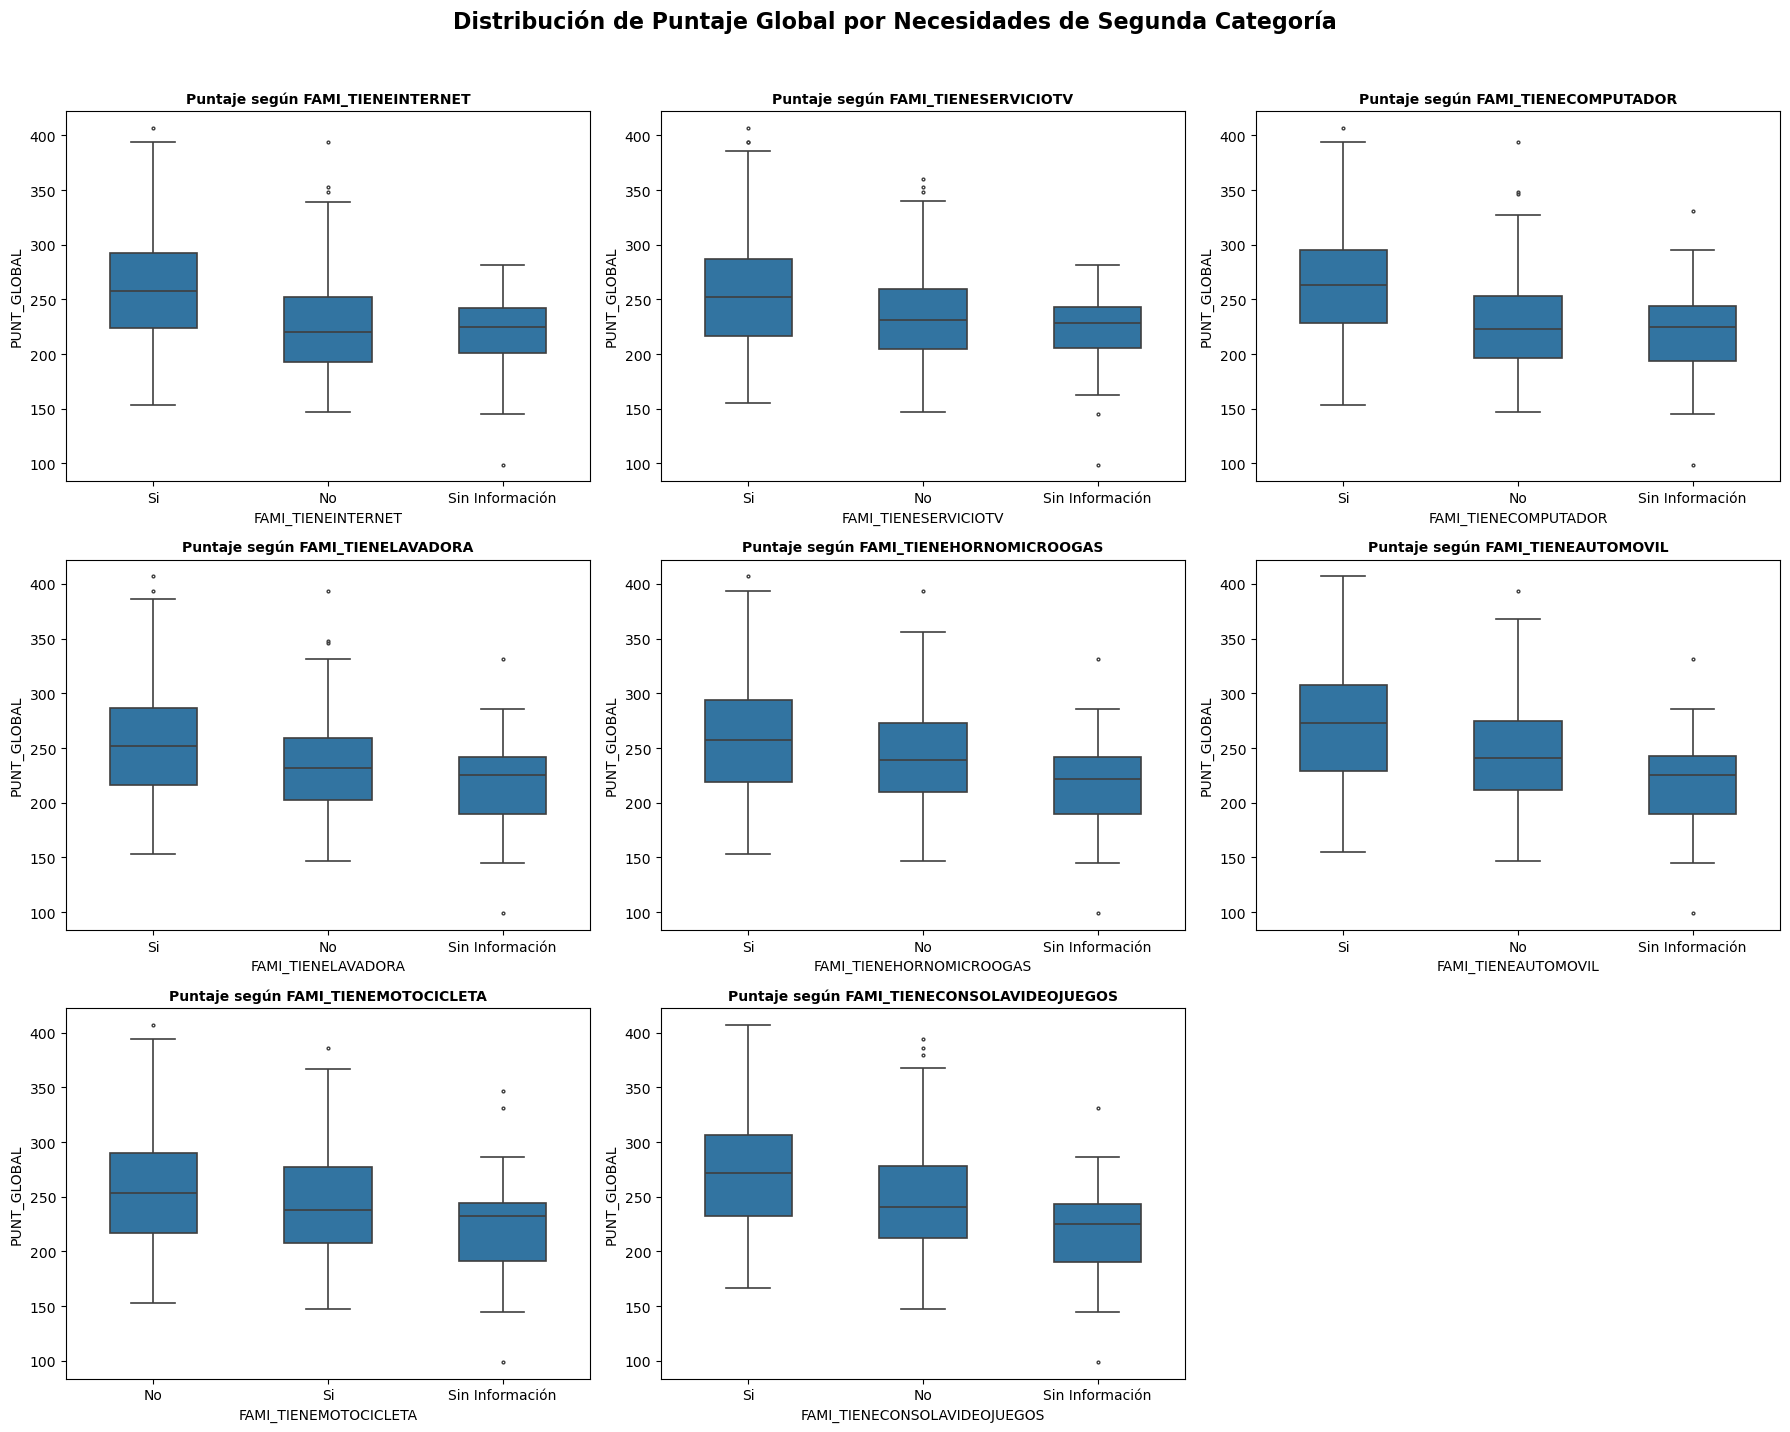

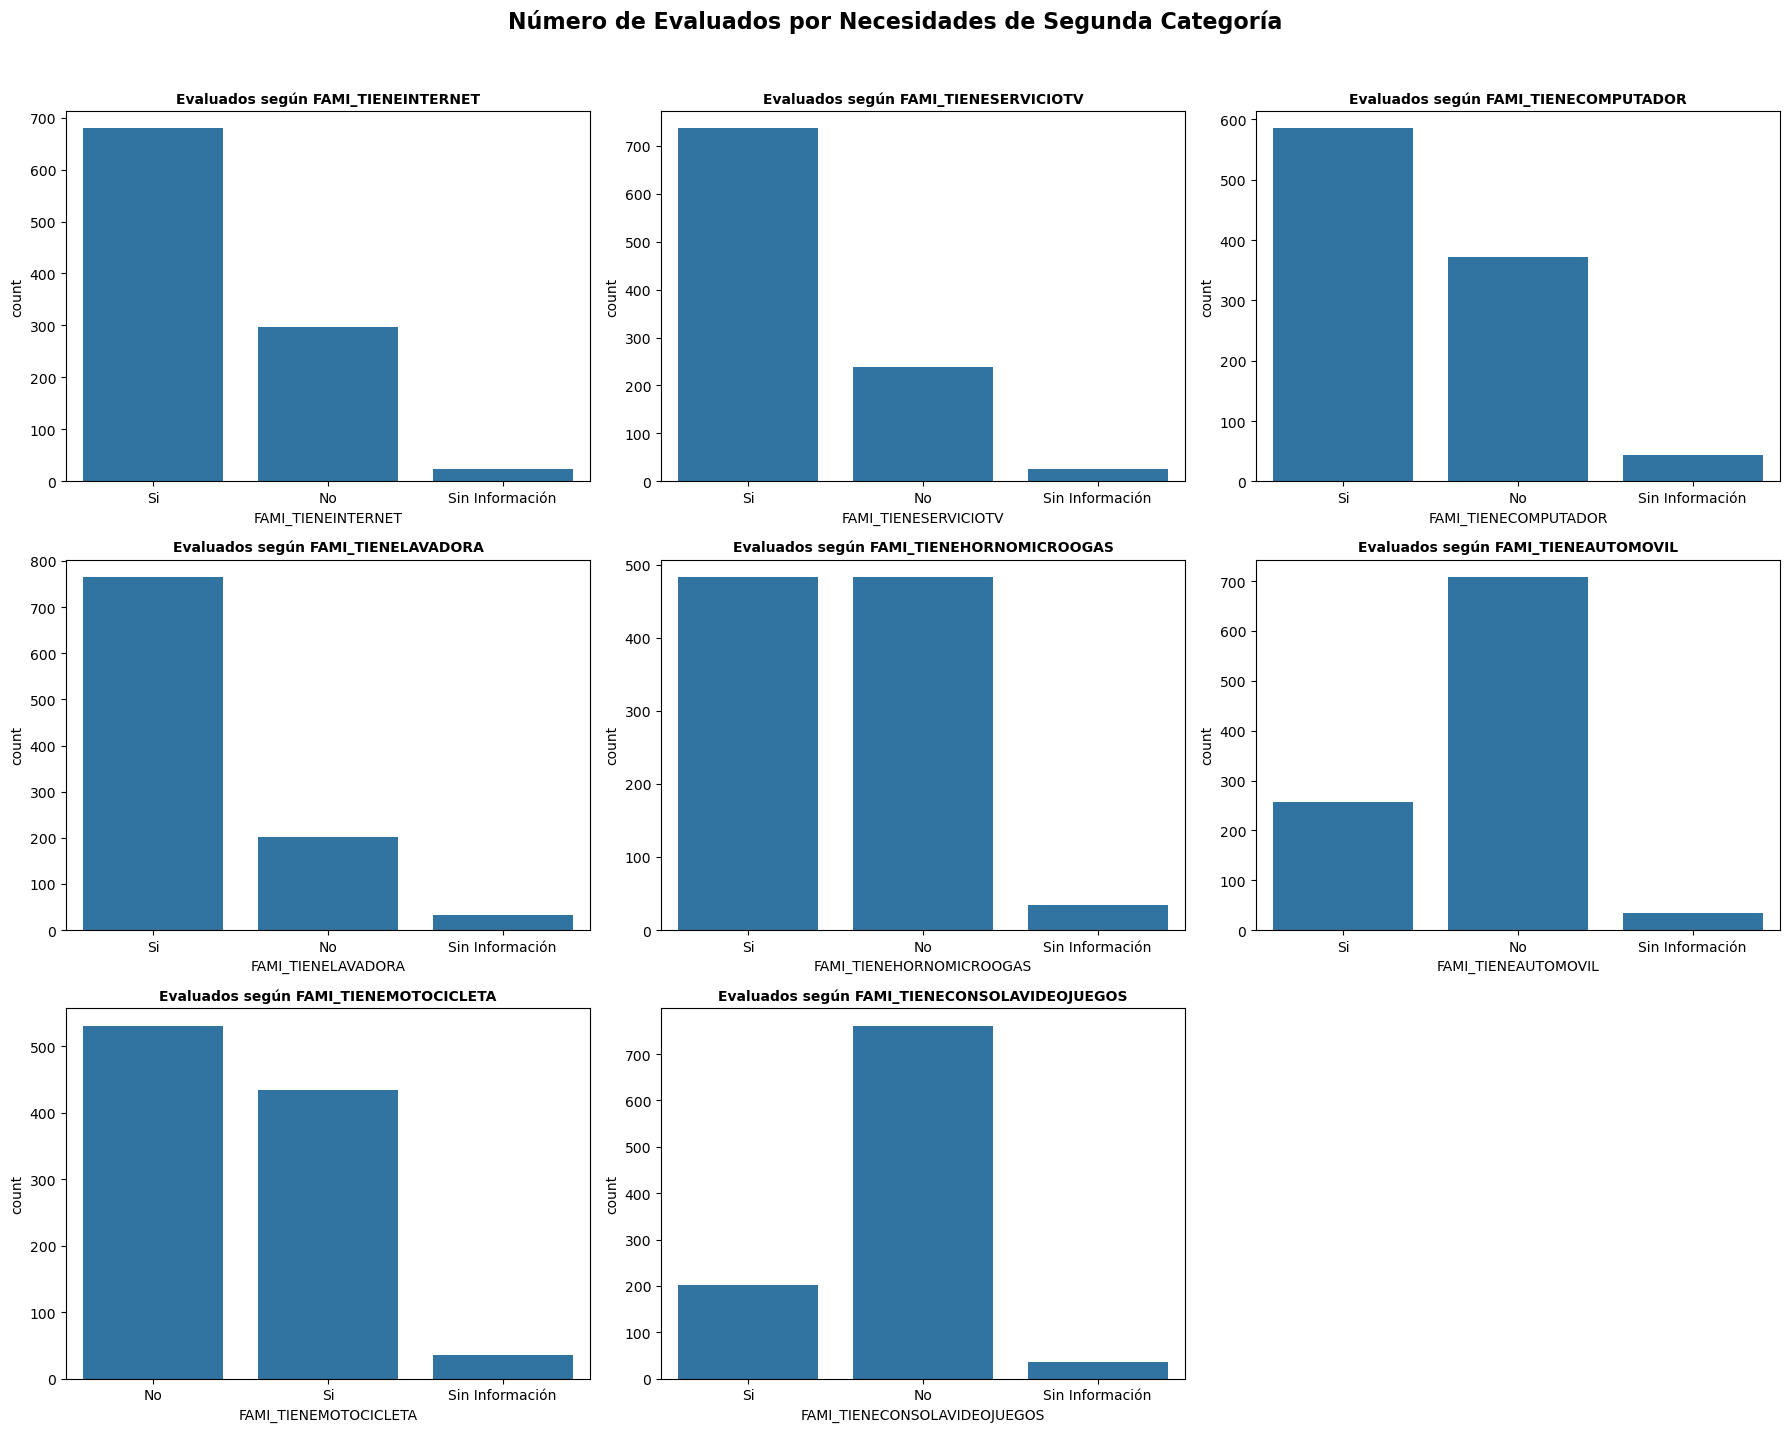

In [10]:
# Crear matriz 3X3 de las variables de Bienestar (boxplot y barras)
bienestar_info = [
    ('FAMI_TIENEINTERNET', estadisticas_tiene_int),
    ('FAMI_TIENESERVICIOTV', estadisticas_tiene_serv_tv),
    ('FAMI_TIENECOMPUTADOR', estadisticas_tiene_pc),
    ('FAMI_TIENELAVADORA', estadisticas_tiene_lavadora),
    ('FAMI_TIENEHORNOMICROOGAS', estadisticas_tiene_microogas),
    ('FAMI_TIENEAUTOMOVIL', estadisticas_tiene_carro),
    ('FAMI_TIENEMOTOCICLETA', estadisticas_tiene_moto),
    ('FAMI_TIENECONSOLAVIDEOJUEGOS', estadisticas_tiene_consola)
]

# Matriz Boxplot.
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()  # Aplanamos la matriz 3x3 a una lista simple de 9 posiciones.

# Recorrer las variables y sus estadísticas para generar la matriz. 
for i, (var, _) in enumerate(bienestar_info):
    ax = axes[i]
    
    sns.boxplot(
        data=df_2020, 
        x=var, 
        y='PUNT_GLOBAL',
        width=0.5,
        fliersize=2,
        linewidth=1.2,
        ax=ax
    )
    ax.set_title(f'Puntaje según {var}', fontsize=10, fontweight='bold')

#Eliminar última casilla, pues las variables sólo son 8.
fig.delaxes(axes[-1])

plt.suptitle('Distribución de Puntaje Global por Necesidades de Segunda Categoría', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Matriz Barras.
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (var, df_est) in enumerate(bienestar_info):
    ax = axes[i]
    
    sns.barplot(
        data=df_est, 
        x=df_est.index, 
        y='count',
        ax=ax
    )
        
    ax.set_title(f'Evaluados según {var}', fontsize=10, fontweight='bold')

fig.delaxes(axes[-1]) # Eliminar última casilla.

plt.suptitle('Número de Evaluados por Necesidades de Segunda Categoría', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# 2. (SOCIO-ECONÓMICA)
# Escogidas por señalar la situación socio-económica que atraviesa al evaluado culturalmente.
# Al igual que las variables de BIENESTAR, estas variables no muestran cambios significativos entre evaluados, a excepción de la educación de padres, donde los hijos/as de padres que culminaron postgrados obtuvieron mejores resultados.

estadisticas_cole_jornada = agrupamiento_por_variable('COLE_JORNADA', 'PUNT_GLOBAL')
estadisticas_estrato = agrupamiento_por_variable('FAMI_ESTRATOVIVIENDA', 'PUNT_GLOBAL')
estadisticas_edu_padre = agrupamiento_por_variable('FAMI_EDUCACIONPADRE', 'PUNT_GLOBAL')
estadisticas_edu_madre = agrupamiento_por_variable('FAMI_EDUCACIONMADRE', 'PUNT_GLOBAL')
estadisticas_num_libros = agrupamiento_por_variable('FAMI_NUMLIBROS', 'PUNT_GLOBAL')

# DataFrame 2.
df_estudio_2 = df_2020[['COLE_JORNADA', 'FAMI_ESTRATOVIVIENDA', 
                  'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
                  'FAMI_NUMLIBROS']].copy()

df_estudio_2['PUNT_GLOBAL'] = df_2020['PUNT_GLOBAL']

# Usar get_dummies para convertir en binario los valores de texto.
df_estudio_2_dummies = pd.get_dummies(df_estudio_2)

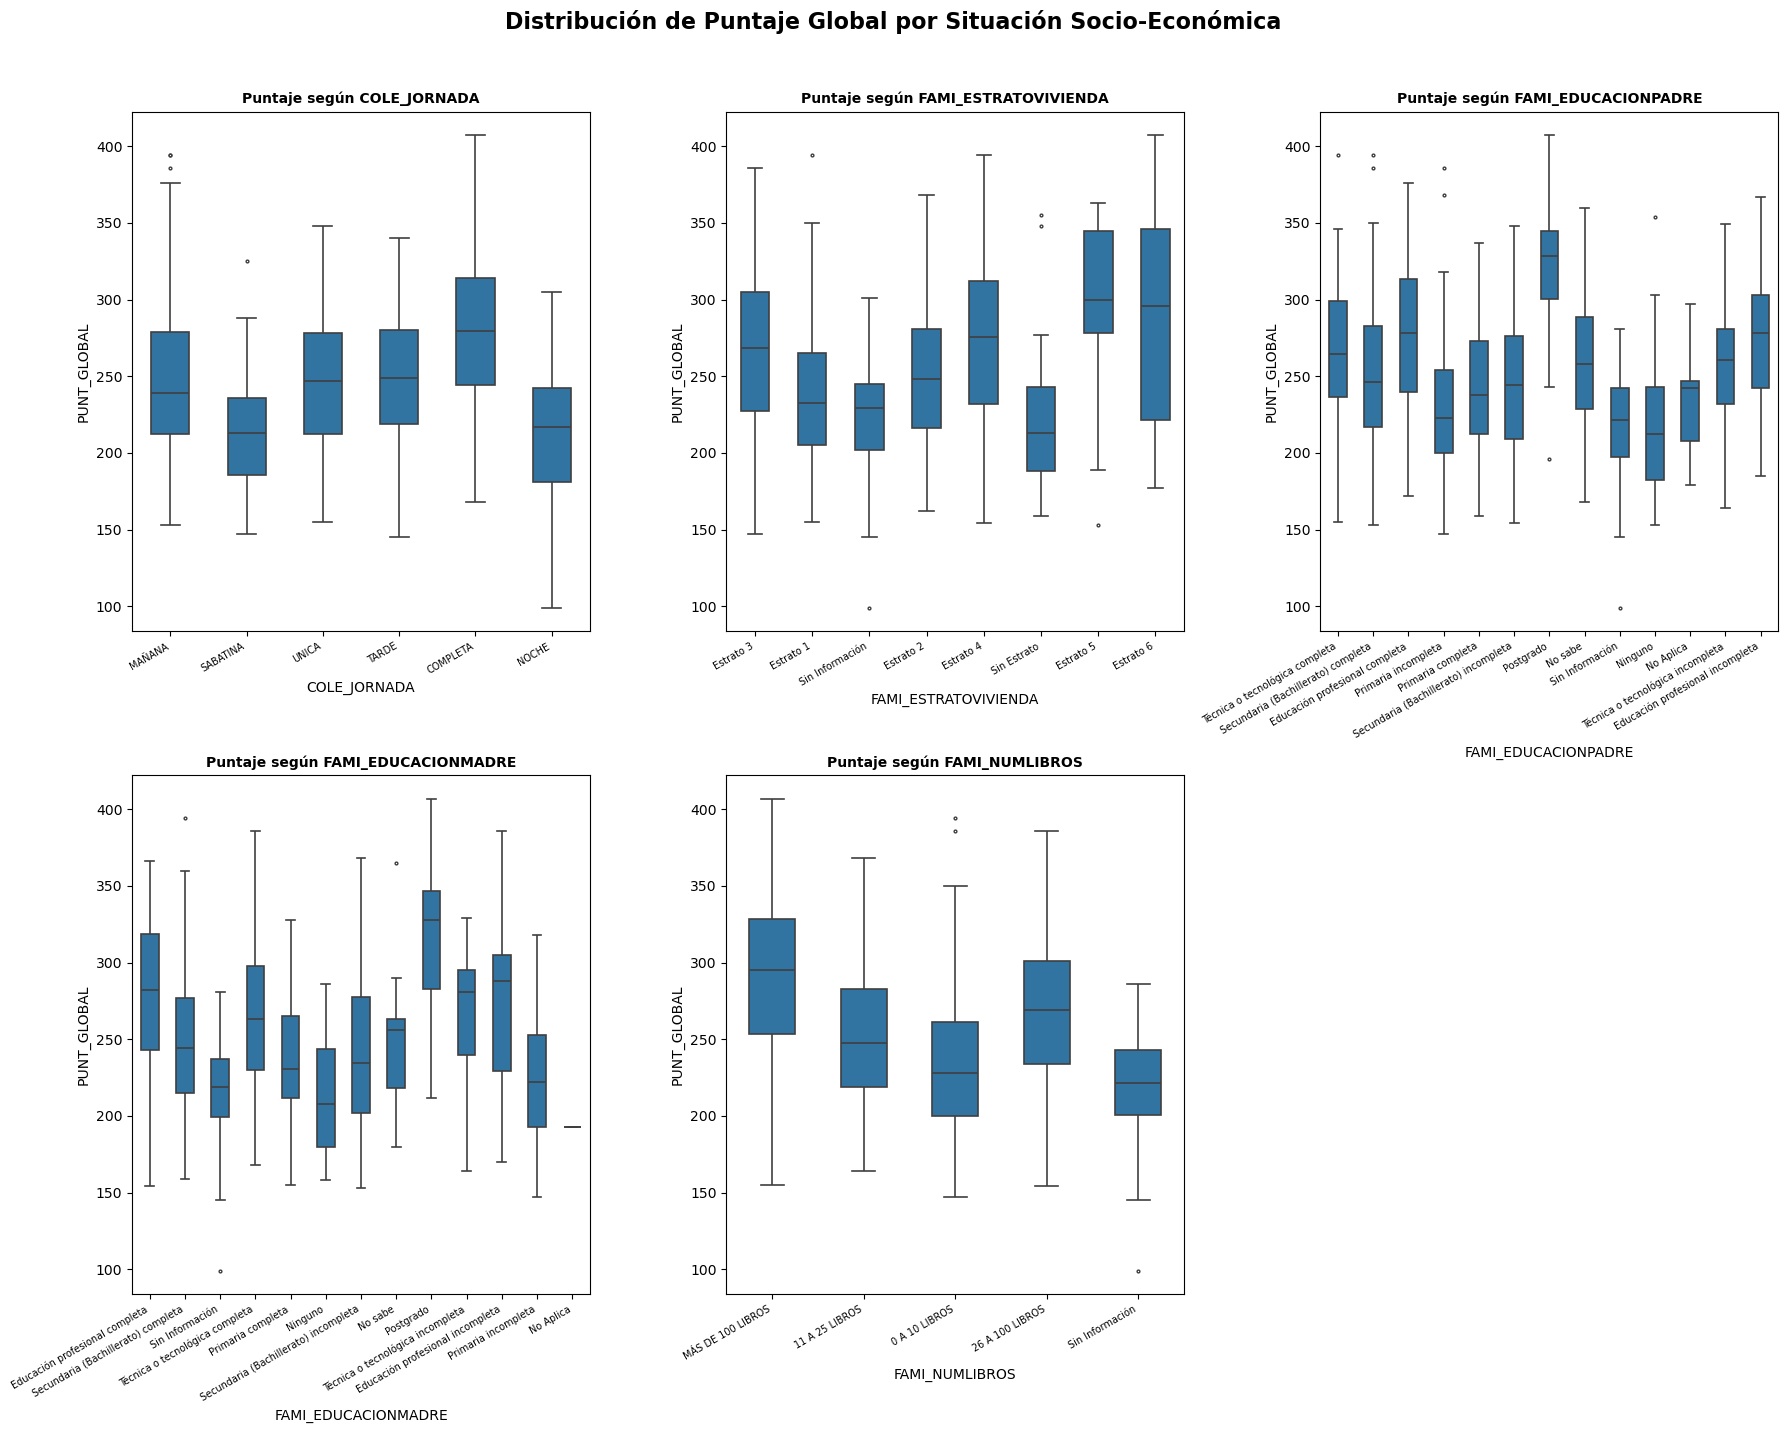

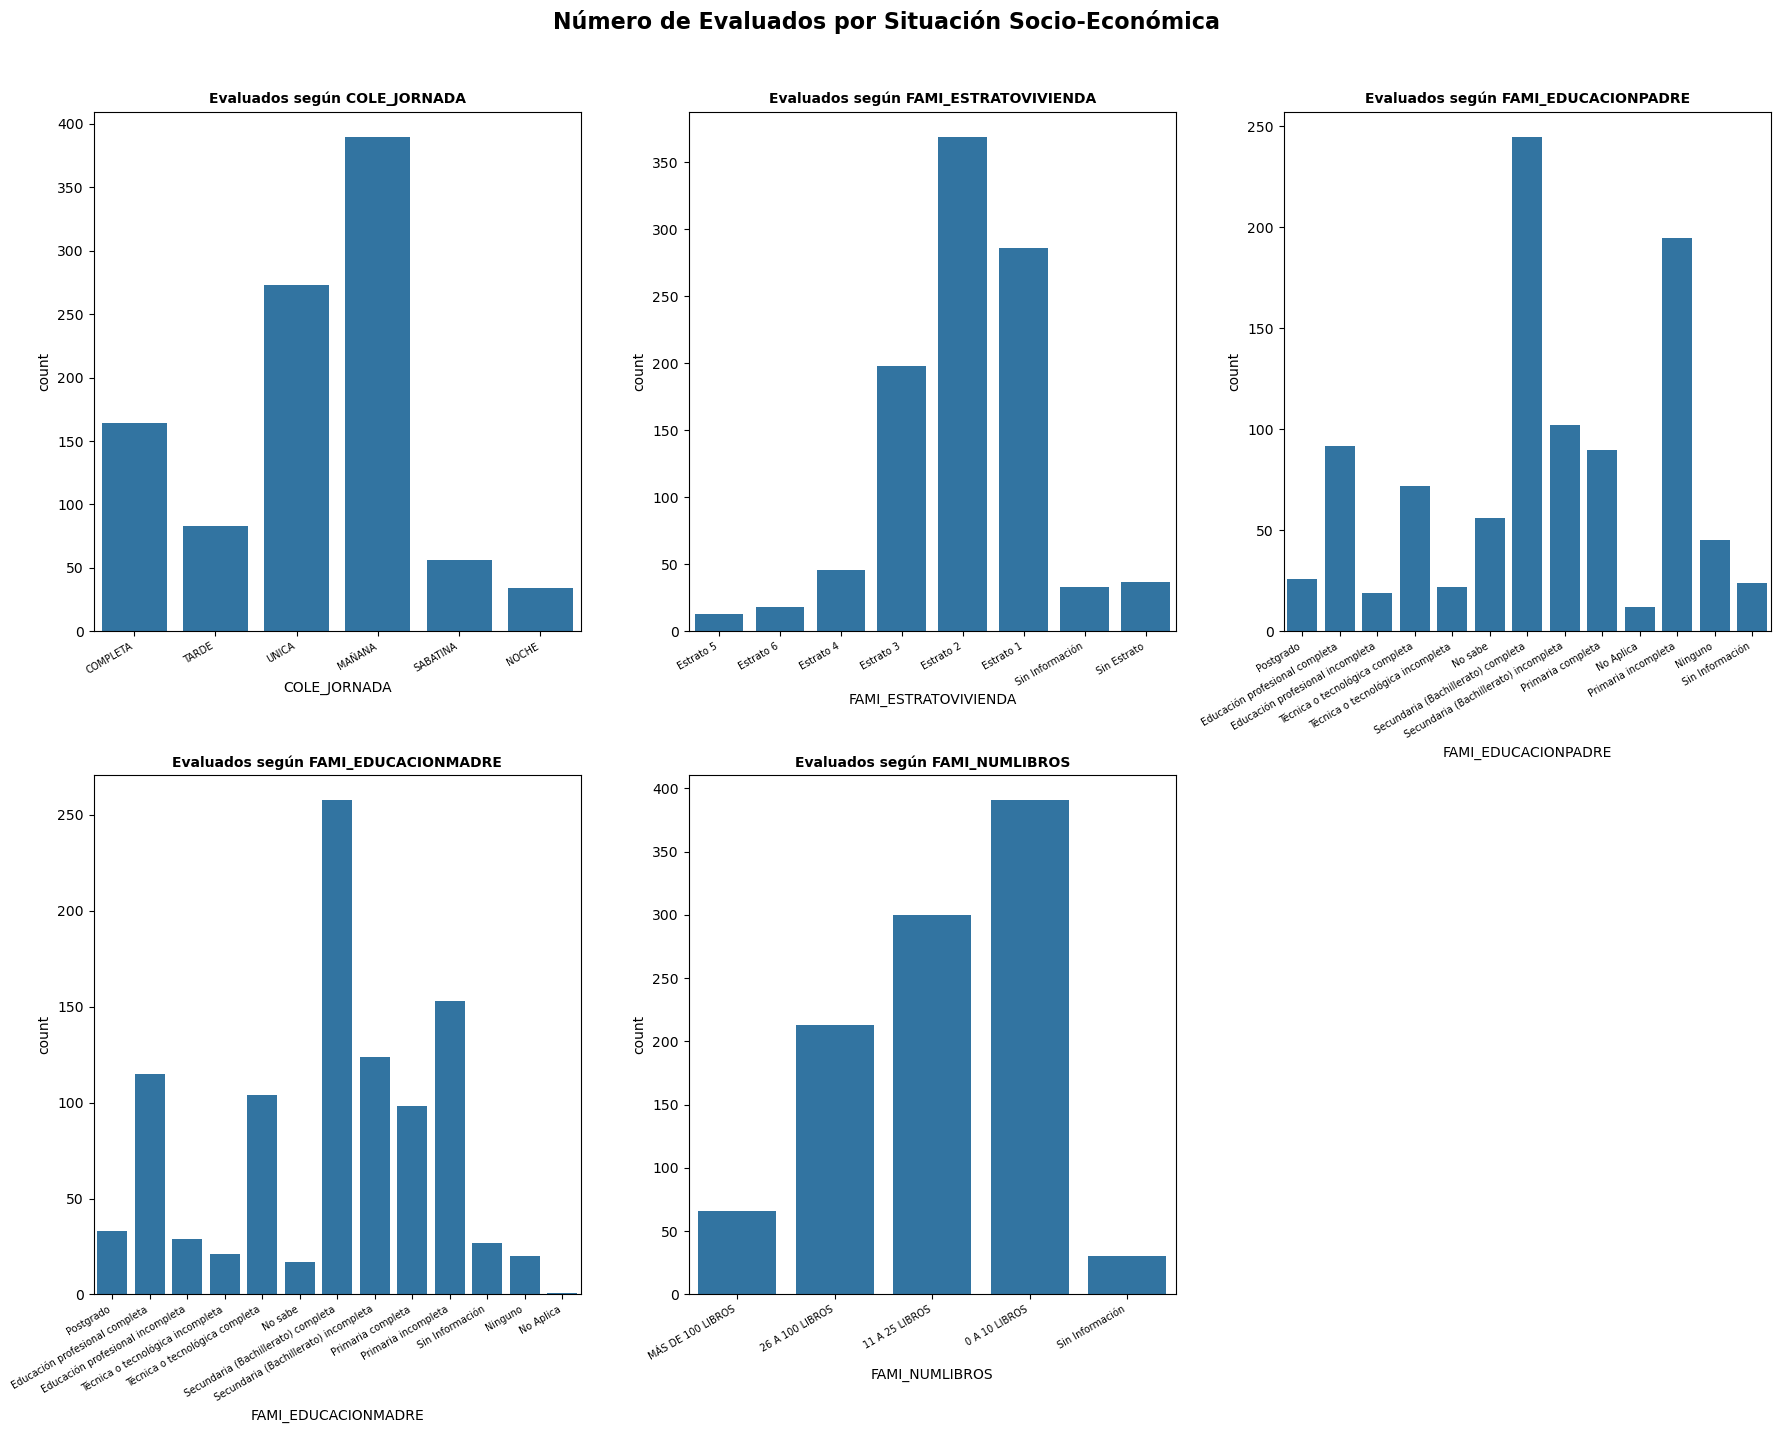

In [12]:
# Crear matriz 3X3 de las variables Socio-Económicas (boxplot y barras)
socioEconomico_info = [
    ('COLE_JORNADA', estadisticas_cole_jornada),
    ('FAMI_ESTRATOVIVIENDA', estadisticas_estrato),
    ('FAMI_EDUCACIONPADRE', estadisticas_edu_padre),
    ('FAMI_EDUCACIONMADRE', estadisticas_edu_madre),
    ('FAMI_NUMLIBROS', estadisticas_num_libros)
]

# Matriz Boxplot.
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()  # Aplanamos la matriz 3x3 a una lista simple de 9 posiciones.

# Recorrer las variables y sus estadísticas para generar la matriz. 
for i, (var, _) in enumerate(socioEconomico_info):
    ax = axes[i]
    
    sns.boxplot(
        data=df_2020, 
        x=var, 
        y='PUNT_GLOBAL',
        width=0.5,
        fliersize=2,
        linewidth=1.2,
        ax=ax
    )

    if len(_.index) > 4:
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        for label in ax.get_xticklabels():
            label.set_ha('right')
        
    ax.set_title(f'Puntaje según {var}', fontsize=10, fontweight='bold')

#Eliminar última casilla, pues las variables sólo son 5.
fig.delaxes(axes[-1])

plt.suptitle('Distribución de Puntaje Global por Situación Socio-Económica', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Matriz Barras.
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (var, df_est) in enumerate(socioEconomico_info):
    ax = axes[i]
    
    sns.barplot(
        data=df_est, 
        x=df_est.index, 
        y='count',
        ax=ax
    )

    if len(df_est.index) > 4:
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        for label in ax.get_xticklabels():
            label.set_ha('right')
        
    ax.set_title(f'Evaluados según {var}', fontsize=10, fontweight='bold')
fig.delaxes(axes[-1]) # Eliminar última casilla.

plt.suptitle('Número de Evaluados por Situación Socio-Económica', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el stakeholder.

Pautas generales:

Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
Utilizar librerías especializadas (ej., statsmodels, sklearn, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.
Preguntas guía:

¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

In [13]:
# Crear función que reciba variable independiente y variable de desempeño para predecir comportamiento y precisión de modelo.
def linear_regression(variable_independiente, variable_desempenio, titulo):
    # Hacer grupos de entrenamiento(80%) y prueba(20%)
    X_train, X_test, y_train, y_test = train_test_split(variable_independiente, variable_desempenio, test_size=0.2, random_state=1)

    # Crear modelo de regresión linear para entrenar y explicar la variable.
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Realizar la predicción.
    prediccion = lr.predict(X_test)

    # Evaluar la precisión del modelo de Regresión Lineal.
    precision_modelo = lr.score(X_test, y_test)

    plt.figure(figsize=(8, 6))
    
    # Scatter plot entre el valor real y la predicción del modelo
    plt.scatter(y_test, prediccion, alpha=0.3, color='royalblue', label='Predicciones')
    
    # Línea diagonal perfecta (donde Real == Predicho)
    min_val = min(y_test.min(), prediccion.min())
    max_val = max(y_test.max(), prediccion.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste')
    plt.ylim(prediccion.min() - 20, prediccion.max() + 20)
    plt.xlim(y_test.min() - 10, y_test.max() + 10)
    
    plt.title(f'{titulo}\n(Precisión modelo: {precision_modelo*100:.2f}%)', fontsize=12, fontweight='bold')
    plt.xlabel('Puntaje Real (y_test)')
    plt.ylabel('Puntaje Predicción (X_test)')
    plt.legend()
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

    return f'Precisión del modelo: {precision_modelo*100:.2f}%'

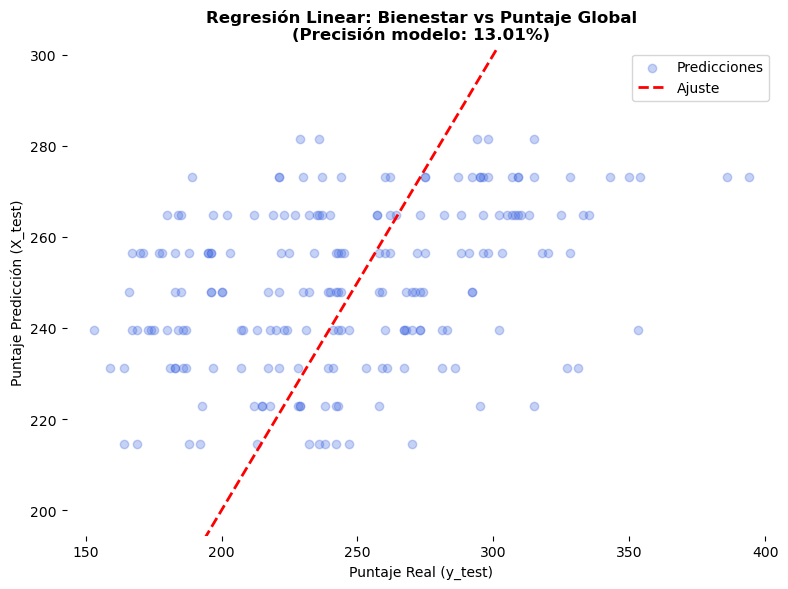

'Precisión del modelo: 13.01%'

In [14]:
# 1.
# Separar las variables independientes de la variable de respuesta (BIENESTAR).
variable_ind_1 = df_estudio_1.copy()[['BIENESTAR']]
variable_des_1 = df_estudio_1.copy()['PUNT_GLOBAL']

# Evaluar el modelo de regresión linear.
linear_regression(variable_ind_1, variable_des_1, 'Regresión Linear: Bienestar vs Puntaje Global')

# El modelo que evalúa estricatmente la posesión de bienes o servicios de segunda necesidad explica 13.01% de los resultados del puntaje global por evaluado.
# Conclusión: La obtención de bienes o servicios de segunda categoría, aunque pueden explicar el 13.01% de los resultados, no es completamente necesario para obtener un buen puntaje en las pruebas saber 11.

# Es prudente evaluar otras varibales para predecir mayor correlación de las mismas con el puntaje global de la prueba.

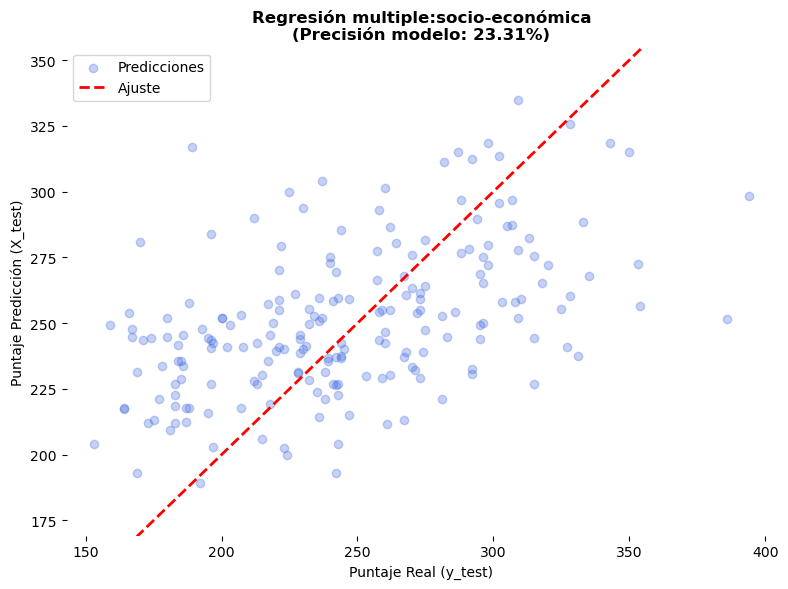

'Precisión del modelo: 23.31%'

In [15]:
#2.
# Separar las variables independientes de la variable de respuesta (SOCIO-ECONÓMICA).
variable_ind_2 = df_estudio_2_dummies.drop('PUNT_GLOBAL', axis=1)
variable_des_2 = df_estudio_2_dummies['PUNT_GLOBAL']

# Evaluar el modelo de regresión linear múltiple.
linear_regression(variable_ind_2, variable_des_2, 'Regresión multiple:socio-económica')

# El modelo evaluando la situación socio-económica del evaluado explica el 23.31% de los resultados del puntaje global por evaluado.
# Conclusión: Las posibilidades brindadas al evaluado según posición socio-económica explican de mejor manera la obtención del puntaje global en las pruebas saber 11

# Es prudente unir las variables de BIENESTAR con las variables SOCIO-ECONÓMICAS para evaluar la predicción según ambas dimensiones por evaluado

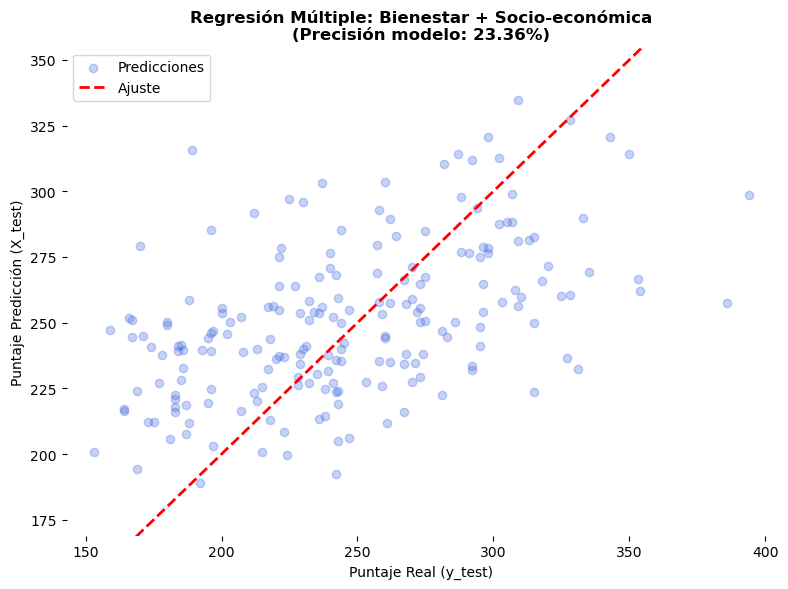

'Precisión del modelo: 23.36%'

In [16]:
# 3
# Variables independientes (BIENESTAR, SOCIO-ECONÓMICAS)
variable_ind_3 = pd.concat([variable_ind_1, variable_ind_2], axis=1)
variable_des_3 = df_estudio_2_dummies['PUNT_GLOBAL']

# Evaluar el modelo de regresión linear múltiple.
linear_regression(variable_ind_3, variable_des_3, 'Regresión Múltiple: Bienestar + Socio-económica')

# Al integrar las variables de bienes de segunda necesidad (BIENESTAR) con el bloque de variables socio-económicas (educación de los padres, estrato, jornada y tenencia de libros), el coeficiente de determinación incrementa levemente del 23.31% al $23.36%. Esto sugiere que gran parte del impacto de la tenencia de bienes en el hogar ya se encuentra capturado por el nivel educativo de los padres y el estrato socioeconómico del estudiante."

 ### Conclusión:
 En conclusión las variables independientes seleccionadas explican, según el coeficiente de determinacion, un 23.36% de los datos con relación al PUNT_GLOBAL obtenido por evaluado. Al ser un porcentaje relativamente pequeño, podemos asegurar que la situación socio-demográfica, al igual que los bienes y servicios, no son determinantes para obtener un buen resultado en las pruebas saber 11. Sin embargo, sí tienen injerencia al momento de presentar la prueba. Pero podemos afirmar que una persona que no esté en la mejor posición socio-económica o que no posea bienes de segunda categoria, aún puede obtener buenos resultados si cumple con varibales que no estén determinadas en este estudio, como motivaciones personales, estudios propios o aptitud académica. 

### Fase 4.
##### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
Utilizar una librería especializada (ej., ipywidgets, panel, etc.) para implementar la herramienta.
Preguntas guía:

¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [17]:
import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Unir variables independientes para la Fase 4
X_fase4 = pd.concat([df_estudio_1[['BIENESTAR']], df_estudio_2_dummies.drop('PUNT_GLOBAL', axis=1)], axis=1)
y_fase4 = df_estudio_2_dummies['PUNT_GLOBAL']

# Entrenar modelo con la matriz completa
modelo_fase4 = LinearRegression()
modelo_fase4.fit(X_fase4, y_fase4)

# 2. Generar opciones dinámicas mapeadas a los nombres exactos del DataFrame
def obtener_opciones(prefijo):
    cols = [c for c in X_fase4.columns if c.startswith(prefijo)]
    # Guarda tupla: (Texto limpio para mostrar, Nombre exacto de la columna)
    return [(c.replace(prefijo, ''), c) for c in cols]

w_bienestar = widgets.IntSlider(value=8, min=0, max=8, step=1, description='BIENESTAR (0-8):')

w_estrato = widgets.Dropdown(
    options=obtener_opciones('FAMI_ESTRATOVIVIENDA_'),
    value='FAMI_ESTRATOVIVIENDA_Estrato 6',
    description='Estrato:'
)

w_edu_padre = widgets.Dropdown(
    options=obtener_opciones('FAMI_EDUCACIONPADRE_'),
    value='FAMI_EDUCACIONPADRE_Postgrado',
    description='Edu. Padre:'
)

w_edu_madre = widgets.Dropdown(
    options=obtener_opciones('FAMI_EDUCACIONMADRE_'),
    value='FAMI_EDUCACIONMADRE_Postgrado',
    description='Edu. Madre:'
)

w_libros = widgets.Dropdown(
    options=obtener_opciones('FAMI_NUMLIBROS_'),
    value='FAMI_NUMLIBROS_MÁS DE 100 LIBROS',
    description='Libros:'
)

w_jornada = widgets.Dropdown(
    options=obtener_opciones('COLE_JORNADA_'),
    value='COLE_JORNADA_COMPLETA',
    description='Jornada:'
)

# 3. Función de simulación
def simular_perfil(bienestar, estrato, edu_padre, edu_madre, libros, jornada):
    # Vector con ceros usando las columnas exactas
    input_data = pd.DataFrame(0.0, index=[0], columns=X_fase4.columns)
    
    # Asignar variable numérica
    input_data['BIENESTAR'] = bienestar
    
    # Activar las columnas dummy seleccionadas (valor = 1.0)
    for col_seleccionada in [estrato, edu_padre, edu_madre, libros, jornada]:
        if col_seleccionada in input_data.columns:
            input_data[col_seleccionada] = 1.0
            
    # Predecir puntaje
    puntaje_predicho = modelo_fase4.predict(input_data)[0]
    
    # Graficar
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.histplot(df_2020['PUNT_GLOBAL'], kde=True, color='gainsboro', ax=ax, label='Distribución Muestra 2020')
    
    ax.axvline(puntaje_predicho, color='firebrick', linestyle='--', linewidth=2.5, 
               label=f'Predicción Perfil: {puntaje_predicho:.1f} pts')
    
    media_global = df_2020['PUNT_GLOBAL'].mean()
    ax.axvline(media_global, color='navy', linestyle=':', linewidth=2, 
               label=f'Media Muestra: {media_global:.1f} pts')
    
    ax.set_title('Simulador de Puntaje Global esperado según perfil del evaluado', fontsize=12, fontweight='bold')
    ax.set_xlabel('Puntaje Global')
    ax.set_ylabel('Frecuencia de Estudiantes')
    ax.legend()
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

# 4. Renderizar Interfaz
ui = widgets.VBox([
    widgets.HBox([w_bienestar, w_estrato, w_jornada]),
    widgets.HBox([w_edu_padre, w_edu_madre, w_libros])
])

out = widgets.interactive_output(simular_perfil, {
    'bienestar': w_bienestar,
    'estrato': w_estrato,
    'edu_padre': w_edu_padre,
    'edu_madre': w_edu_madre,
    'libros': w_libros,
    'jornada': w_jornada
})

display(ui, out)

Output()

En el panel interactivo se puede ajustar el bienestar (enmarcado en la enumeración de bienes o servicios de 2da categoría) y la situación socioedemográfica por evaluado (estrato de vivienda, educación de los padres, jornada escolar y cantidad de libros en casa). Ajustando individualmente cada valor la gráfica visualizará el puntaje probable que el perfil de dicho evaluado puede tener en las pruebas saber 11. De esta manera el usuario de la herramienta puede aventurarse a medir, según sistuación personal, cuál es el puntaje que puede lograr en las pruebas saber 11, con base en los datos recogidos del año 2020. Cabe aclarar, como ya se mencionó en la conclusión de la fase anterior, esta predicción solo explica el 23.4% de los datos. Por lo tanto, se anima al estudiante a preparar un excelente examen, para que los resultados sean igualmente excelentes. Pues la predicción está lejos de abordar la mayoría de los casos examinados.  